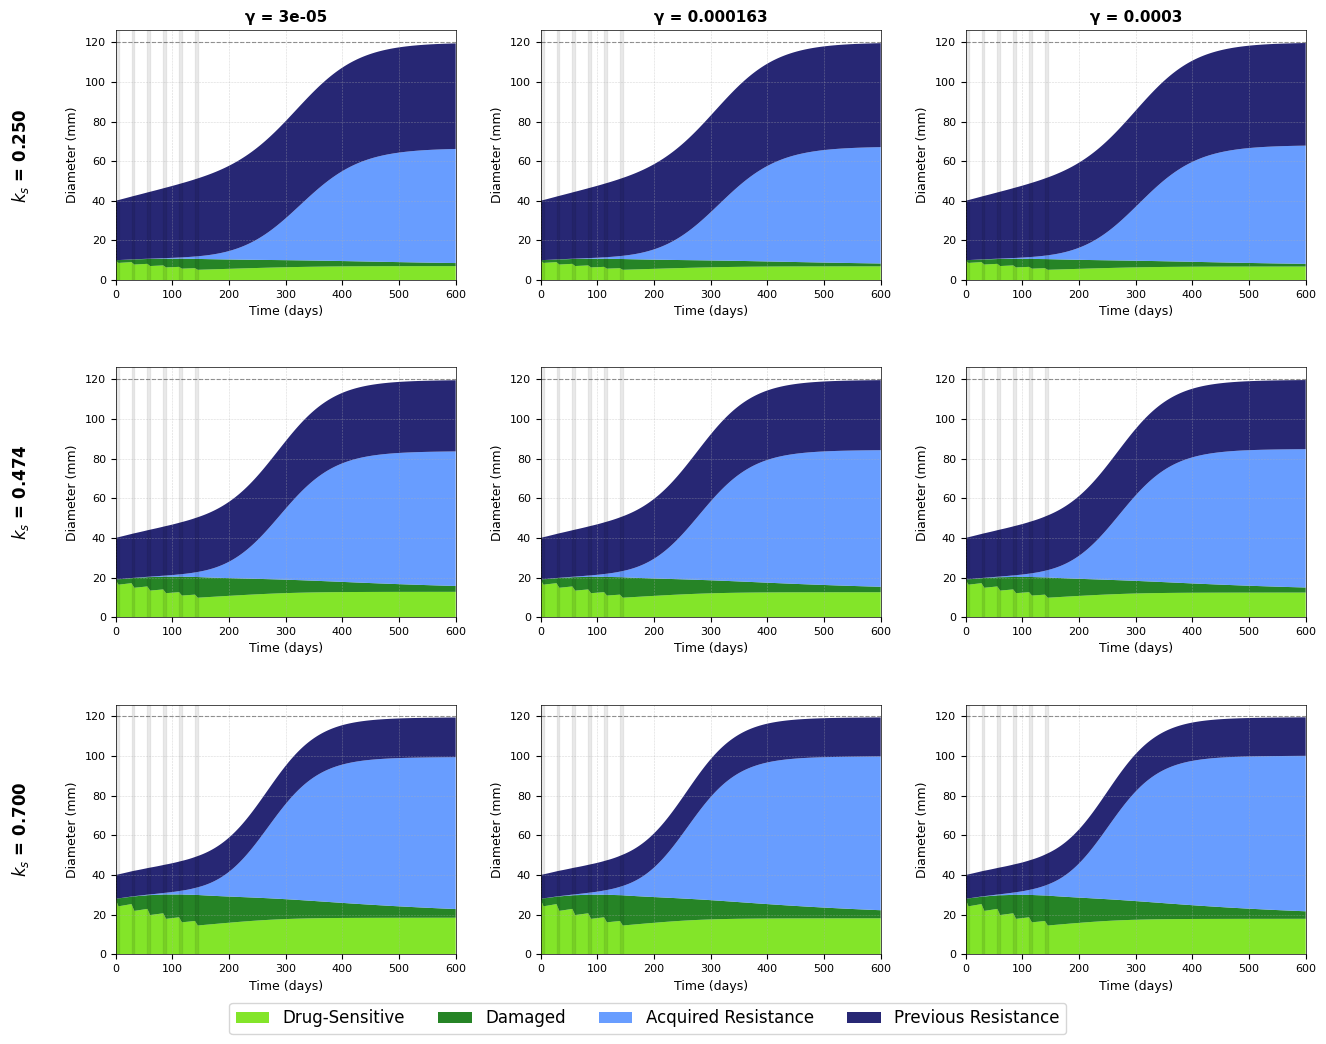

In [9]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

'''Parameters'''
# Tumor growth parameters
G = 0.003 # day^-1, proliferation rate
delta_RA = 11 # factor increase in proliferation rate for acquired resistant cells
tau_SD = 0.0382 # L/g/day, rate at which sensitive cells (S) are converted to damaged cells (D).
tau_DR = 0.000544 # day^-1, rate at which damaged cells (D) are converted to resistant cells (R).
mu_D = 0.00219 # day^-1, death rate for damaged cells (D)
gamma = 0.000136 # L/(mg·day), rate at which damaged cells can repair their DNA, allowing them to become resistant
k_s = 0.474 # proportion of P0 that is sensitive
P0 = 40 # mm, initial total tumour diameter
K = 120 # mm, carrying capacity

# Initial tumour cell conditions
S0 = k_s * P0
RP0 = (1 - k_s) * P0
D0 = 0
RA0 = 0

# Chemotherapeutic pharmacokinetics (PK) parameters
Ka = 5.8*24 # day^-1, absorption rate constant
CL = 10.0*24 # L/day, oral clearance
VD = 30.3 # L, volume of distribution in plasma/tissue
Vp = 0.14 # L, volume of distribution in CSF
k23 = 7.2e-4*24 # day^-1, transfer rate constant from the plasma to CSF
k32 = 0.14*24 # day^-1, back transfer rate constant from the CSF to plasma

'''Dosing Schedule'''
# 6 cycles, 175 mg/day for first 5 days of each 28-day cycle
DOSE_MG = 175.0 # dose (mg)
CYCLE_DAYS = 28
DOSE_DAYS = 5
N_CYCLES = 6
T_END = N_CYCLES * CYCLE_DAYS + 1000 # total days

def get_dose_times():
    """Return list of day numbers when a dose is given (day 0-indexed)."""
    times = []
    for c in range(N_CYCLES):
        start = c*CYCLE_DAYS
        for d in range(DOSE_DAYS):
            times.append(start + d)
    return times

'''Define ODEs that make up compartment model'''
# Drug compartments
def dA1(A1):
    return -Ka * A1

def dA2(A1, A2):
    return Ka * A1 - (CL / VD) * A2 - k23 * A2

def dA3(A2, A3):
    return k23 * A2 - k32 * A3

# Tumour compartments
def dS(S, N, C_CSF, G, tau_SD):
    return G * S * (1.0 - N / K) - tau_SD * C_CSF * S

def dD(S, D, C_CSF, tau_SD, tau_DR, mu_D, gamma):
    return tau_SD * C_CSF * S - (tau_DR + mu_D + gamma) * D

def dRA(RA, D, N, G, tau_DR, gamma, delta_RA):
    return G * (1 + delta_RA) * RA * (1.0 - N / K) + tau_DR * D + gamma * D

def dRP(RP, N, G):
    return G * RP * (1.0 - N / K)

'''Simulate and plot model'''
def simulate(ks=None, gam=None, t_end=None):
    """Run simulation with optional overrides for k_s and gamma."""
    _ks   = ks    if ks    is not None else k_s
    _gam  = gam   if gam   is not None else gamma
    _tend = t_end if t_end is not None else T_END

    _S0  = _ks * P0
    _RP0 = (1 - _ks) * P0

    dose_times = get_dose_times()
    y0 = [_S0, 0.0, 0.0, _RP0, 0.0, 0.0, 0.0]

    all_t, all_y = [], []
    t_current = 0.0
    y_current = np.array(y0)

    events = sorted(set(dose_times + [_tend]))

    def gbm_odes(t, y):
        S, D, RA, RP, A1, A2, A3 = y
        C_CSF = A3 / Vp
        N     = S + D + RA + RP
        return [
            dS( S, N, C_CSF, G, tau_SD),
            dD( S, D, C_CSF, tau_SD, tau_DR, mu_D, _gam),
            dRA(RA, D, N, G, tau_DR, _gam, delta_RA),
            dRP(RP, N, G),
            dA1(A1),
            dA2(A1, A2),
            dA3(A2, A3),
        ]

    for t_event in events:
        if t_event <= t_current:
            y_current[4] += DOSE_MG
            continue

        sol = solve_ivp(
            gbm_odes,
            [t_current, t_event],
            y_current,
            method='LSODA',
            max_step=0.1,
            rtol=1e-8,
            atol=1e-10,
            dense_output=False,
        )

        if not sol.success:
            raise RuntimeError(f"Integration failed at t={t_current}: {sol.message}")

        all_t.append(sol.t[:-1])
        all_y.append(sol.y[:, :-1])

        t_current = sol.t[-1]
        y_current = sol.y[:, -1].copy()

        if t_event in dose_times and t_event < _tend:
            y_current[4] += DOSE_MG

    all_t.append([t_current])
    all_y.append(y_current.reshape(-1, 1))

    t = np.concatenate(all_t)
    y = np.concatenate(all_y, axis=1)

    return t, y

def plot_parameter_sweep():
    """3×3 grid of tumour composition plots with varying k_s (rows) and gamma (columns)."""
    ks_values = [0.250, 0.474, 0.700]
    gamma_values = [0.00003, 0.000163, 0.0003]

    # TIme period displayed in plots
    T_SWEEP = 600 # days

    dose_times = get_dose_times()

    fig, axes = plt.subplots(
        3, 3,
        figsize=(14, 11),
        sharex=True, sharey=True
    )

    sweep_palette = {
        "S":  "#6DE103",
        "D":  "#006F00",
        "RA": "#4D8CFF",
        "RP": "#01015C",
    }

    for row_idx, ks_val in enumerate(ks_values):
        for col_idx, gam_val in enumerate(gamma_values):

            ax = axes[row_idx][col_idx]

            # Run simulation
            t, y = simulate(ks=ks_val, gam=gam_val, t_end=T_SWEEP)
            S, D, RA, RP = y[0], y[1], y[2], y[3]

            # Clip to T_SWEEP
            mask = t <= T_SWEEP
            t_p, S_p, D_p, RA_p, RP_p = t[mask], S[mask], D[mask], RA[mask], RP[mask]

            # Stacked area chart
            ax.stackplot(
                t_p, S_p, D_p, RA_p, RP_p,
                colors=[sweep_palette["S"], sweep_palette["D"],
                        sweep_palette["RA"], sweep_palette["RP"]],
                alpha=0.85
            )

            # Carrying capacity line
            ax.axhline(K, color="black", lw=0.8, linestyle="--", alpha=0.4)

            # Dosing windows shading
            for c in range(N_CYCLES):
                start = c * CYCLE_DAYS
                end   = start + DOSE_DAYS
                if start < T_SWEEP:
                    ax.axvspan(start, min(end, T_SWEEP), alpha=0.075, color="black")

            # Styling
            ax.set_xlim(0, T_SWEEP)
            ax.set_ylim(0, K * 1.05)
            ax.grid(linewidth=0.4, linestyle="--", alpha=0.5)
            for spine in ax.spines.values():
                spine.set_linewidth(0.5)
            ax.tick_params(labelsize=8)

            # Column headers (γ values)
            if row_idx == 0:
                ax.set_title(f"γ = {gam_val:.5g}", fontsize=11, pad=6, fontweight="bold")

            # Row labels (k_s values)
            if col_idx == 0:
                ax.set_ylabel("Diameter (mm)", fontsize=9)
                ax.text(
                    -0.28, 0.5, f"$k_s$ = {ks_val:.3f}",
                    transform=ax.transAxes,
                    fontsize=12, fontweight="bold",
                    va="center", ha="center", rotation=90
                )

            ax.set_xlabel("Time (days)", fontsize=9)
            ax.set_ylabel("Diameter (mm)", fontsize=9)
            ax.tick_params(axis='x', labelbottom=True)
            ax.tick_params(axis='y', labelleft=True)
    
    # Shared legend at bottom
    legend_elements = [
        mpatches.Patch(facecolor=sweep_palette["S"],  alpha=0.85, label="Drug-Sensitive"),
        mpatches.Patch(facecolor=sweep_palette["D"],  alpha=0.85, label="Damaged"),
        mpatches.Patch(facecolor=sweep_palette["RA"], alpha=0.85, label="Acquired Resistance"),
        mpatches.Patch(facecolor=sweep_palette["RP"], alpha=0.85, label="Previous Resistance"),
    ]
    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=7,
        fontsize=12,
        frameon=True,
        bbox_to_anchor=(0.5, 0.01),
    )

    plt.subplots_adjust(left=0.12, right=0.97, top=0.93, bottom=0.09, hspace=0.35, wspace=0.25)

'''Run and plot model'''
plot_parameter_sweep()